In [33]:
print("Hello")

Hello


In [3]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device()#drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
) 

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 63036)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 49811)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 46243)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 38951)

# #### Device() ####
# device = cuda:4

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:4)
# edge_attr                (32464, 16)              Tensor (cuda:4)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:4)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

---

In [4]:
from modules.train import Loader
from modules.data import GraphDataset

from torch_geometric.loader import DataLoader
from modules.data import GraphDataset
from modules.utils import dict_summary
from collections import defaultdict

# typing
import torch
import torch.nn as nn
from torch import Tensor
from torch_geometric.data import Data, Batch


In [5]:
def load_model(model, state_dict_path:str, device:str, dataset:GraphDataset|None=None, batch_size:int=128):
    # init with loader
    init_fn = getattr(model, 'init_with_loader', None)
    if callable(init_fn) and dataset is not None:
        loader = Loader(dataset, device=device, batch_size=batch_size)
        init_fn(loader)

    # load state dict
    state_dict = torch.load(state_dict_path, map_location=device)
    model.load_state_dict(state_dict)

    # set model to eval
    model.eval()   

class ModelOut2():
    def __init__(self, model:nn.Module, dataset:GraphDataset, batch_size:int=64, **fwd_kwargs):
        fwd_kwargs = fwd_kwargs if fwd_kwargs is not None else {}

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        x_list = []
        y_list = []
        out_list = []

        for batch in loader:
            out = model(batch, **fwd_kwargs)
            out = self._detach_items(out)
            out_list.append(out)
            x_list.append(batch.x)
            y_list.append(batch.y)

        self.x = torch.cat(x_list, dim=0).reshape(-1, dataset.wrapper.num_nodes).cpu()
        self.y = torch.cat(y_list, dim=0).cpu()
        self.out = self._transpose_values(out_list)

    def _detach_items(self, item):
        # single tensor
        if isinstance(item, Tensor):
            return item.detach().cpu()

        # list/tuple (recursive)
        if isinstance(item, (list, tuple, set)):
            return type(item)(self._detach_items(i) for i in item)

        # dict, PyG Data/DataBatch
        if isinstance(item, (dict, Data, Batch)):
            return {key: self._detach_items(value) for key, value in item.items()}
        
        # other class with .x
        if hasattr(item, 'x'):
            return {
                'x': self._detach_items(item.x),
                'y': self._detach_items(getattr(item, 'y', None)),
                'sample_id': self._detach_items(getattr(item, 'sample_id', None))
            }
        
        # fallback
        return item

    def _transpose_values(self, values) -> dict:
        out = defaultdict(list)

        # collect
        for v in values:
            for k, val in v.items():
                out[k].append(val)

        # concat if tensor
        for k, vals in out.items():
            v0 = vals[0]

            if torch.is_tensor(v0):
                if v0.ndim == 0: # scalar tensor -> stack
                    out[k] = torch.stack(vals, dim=0)

                # elif v0.ndim == 1: # vector tensor -> concat

                else: # batched tensor -> concat on batch dim
                    out[k] = torch.cat(vals, dim=0)
            
            elif isinstance(v0, dict): # dict -> recursively concat
                out[k] = self._transpose_values(vals)

            else:
                out[k] = vals

        return dict(out) 

---

In [ ]:
from modules.layers import AttentionSetPooling
from modules.model import MultiLatentModel
from modules.norm import LogCounts
from modules.train import MultiTrainer, MultiTrainerStage, Experiment, grid, Loader
from modules.trainers import ReconstrTrainer, ClassifTrainer
from modules.loss import NBLoss, KLDLoss, MultiLoss

import torch
import torch.nn as nn
from functools import partial

# multihead model
model = MultiLatentModel(
    dataset = dataset,
    embed_dim = 128,
    # head_dim = None (default)
    # num_heads = 1 (default)
    method = 'set',

    # layers
    norm_class = LogCounts,
    encoder_class = nn.Linear,
    pooling_class = AttentionSetPooling,
    mlp = False,
    variational = True,
    # out_module = nn.Linear (default)

    # layer params
    hidden_dims = 1,
    act_fn = nn.ReLU, 
    norm_fn = 'layer', 
    end_fn = False,

    # kwargs
    norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True}
    # pooling_kwargs = None (default)
)

load_model(
    model=model,
    state_dict_path='output/2026-01-20_18h51m04s_benchmark_2_attn/pathway_vae/pathway_vae_trial_0_model.pth',
    device=device,
    dataset=dataset,
)

vals = ModelOut2(model, dataset, need_weights=True)

---
# viz

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from tqdm import tqdm

In [8]:
class AttnViz():
    def __init__(self, vals, dataset, pnames_dir:str, mode:str['ae','cl']='ae'):
        self.vals = vals
        self.dataset = dataset
        self.mode = mode

        # from dataset
        self.y_labels = dataset.wrapper.y_labels
        self.x_labels = dataset.wrapper.x_labels
        self.pathway_index = dataset.wrapper.pathway_index

        # pathway labels
        self.pathway_labels = [s.replace('path:', '') for s in dataset.wrapper.pathway_labels]
        self.pathway_names = pd.read_csv(pnames_dir, index_col=0).loc[self.pathway_labels, 'name'].str.replace(' - Homo sapiens (human)', '').to_list()
        
        # get attn
        self.np = vals.out['layer_outs']['np']['attn'] # 1172,4373,305
        self.lp = vals.out['layer_outs'][f'lp_{mode}']['attn'].squeeze() # 1172,305
        self.joint = self.lp.unsqueeze(1) * self.np # 1172,4373,305
        self.split = {int(c): self.joint[self.vals.y == c] for c in torch.unique(self.vals.y)}

        # get dfs
        self.gene, self.gene_stats, self.gene_adj = self._get_df('gene')
        self.pathway, self.pathway_stats, self.pathway_adj = self._get_df('pathway')

    def _get_df(self, level:str['gene','pathway']):
        if level == 'gene':
            sum_on = 1
            idx = self.x_labels
        elif level == 'pathway':
            sum_on = 0
            idx = self.pathway_names
        else:            
            raise ValueError(f"Invalid level: {level}. Must be 'gene' or 'pathway'.")

        # get attn dfs
        df = pd.DataFrame({i: self.split[i].mean(0).sum(sum_on) for i in self.split})
        df = df.rename(columns=dict(enumerate(self.y_labels)))
        df.index = idx

        # get df_stats
        n = self.pathway_index.sum(sum_on).tolist()
        micro_avg = df.mean(1)
        df_stats = pd.DataFrame({'n': n, 'micro_avg': micro_avg})

        # get lowess
        df_stats['lowess'] = sm.nonparametric.lowess(df_stats['micro_avg'], df_stats['n'], frac=0.3, return_sorted=False)
        df_stats['resid'] = df_stats['micro_avg'] - df_stats['lowess']
        df_stats['z'] = (df_stats['resid'] - df_stats['resid'].mean()) / df_stats['resid'].std()

        # get df_adj for viz
        df_adj = df.sub(df_stats['lowess'], axis=0)

        return df, df_stats, df_adj

In [9]:
attn = AttnViz(
    vals = vals, 
    dataset = dataset, 
    pnames_dir = dataset_dir/'other'/'pathway_names.csv', 
    mode='cl'
)

/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


---
# topk genes per pathway

In [10]:
import torch
import pandas as pd

def topk_genes_for_pathways(
    attn: torch.Tensor,
    query_pathways: list[str],
    pathway_names: list[str],
    gene_names: list[str],
    k: int = 10,
    reduce: str = "mean",
    normalize_within_pathway: bool = False,
):
    """
    attn: (samples, genes, pathways)
    query_pathways: pathway names to query
    pathway_names: all pathway names, same order as attn dim=2
    gene_names: all gene names, same order as attn dim=1
    k: top k genes per pathway
    reduce: "mean" or "sum" across samples
    normalize_within_pathway:
        False = global attention score
        True  = gene attention conditional on pathway
    """

    assert attn.ndim == 3
    assert attn.shape[1] == len(gene_names)
    assert attn.shape[2] == len(pathway_names)

    pathway_to_idx = {p: i for i, p in enumerate(pathway_names)}

    missing = [p for p in query_pathways if p not in pathway_to_idx]
    if missing:
        raise ValueError(f"Pathways not found: {missing}")

    if normalize_within_pathway:
        attn = attn / attn.sum(dim=1, keepdim=True).clamp_min(1e-12)

    if reduce == "mean":
        score_mat = attn.mean(dim=0)   # (genes, pathways)
    elif reduce == "sum":
        score_mat = attn.sum(dim=0)    # (genes, pathways)
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")

    rows = []

    for pathway in query_pathways:
        p_idx = pathway_to_idx[pathway]

        scores = score_mat[:, p_idx]  # (genes,)
        vals, idx = torch.topk(scores, k=min(k, scores.numel()))

        for rank, (gene_idx, score) in enumerate(
            zip(idx.cpu().tolist(), vals.cpu().tolist()),
            start=1
        ):
            rows.append({
                "pathway": pathway,
                "pathway_idx": p_idx,
                "rank": rank,
                "gene": gene_names[gene_idx],
                "gene_idx": gene_idx,
                "attention": score,
            })

    return pd.DataFrame(rows)

In [11]:
df_top = topk_genes_for_pathways(
    attn=attn.joint,
    query_pathways=[
        # "Basal cell carcinoma",
        # "Drug metabolism - cytochrome P450",
        # "ECM-receptor interaction",
        'Primary bile acid biosynthesis',
        ],
    pathway_names=attn.pathway_names,
    gene_names=attn.x_labels,
    k=10,
    reduce="mean",
    normalize_within_pathway=False,
)
df_top

,pathway,pathway_idx,rank,gene,gene_idx,attention
0,Primary bile acid biosynthesis,90,1,HSD3B7,672,0.001962
1,Primary bile acid biosynthesis,90,2,HSD17B4,1873,0.001942
2,Primary bile acid biosynthesis,90,3,ACOX2,3113,0.001482
3,Primary bile acid biosynthesis,90,4,CYP27A1,1968,0.001407
4,Primary bile acid biosynthesis,90,5,SLC27A5,518,0.001231
5,Primary bile acid biosynthesis,90,6,AMACR,4273,0.001078
6,Primary bile acid biosynthesis,90,7,CYP46A1,173,0.001076
7,Primary bile acid biosynthesis,90,8,CH25H,2081,0.001051
8,Primary bile acid biosynthesis,90,9,CYP39A1,2364,0.000994
9,Primary bile acid biosynthesis,90,10,SCP2,1321,0.000789


In [18]:
# attn.gene_stats.sort_values('micro_avg', ascending=False).head(20)

In [19]:
# attn.pathway_adj.loc[attn.pathway_stats.sort_values('z', ascending=False).index[:50]]

In [20]:
# sns.heatmap(attn.pathway_adj.loc[attn.pathway_stats.sort_values('z', ascending=False).index[:50]])

In [ ]:
# sns.displot(attn.pathway_adj.values.flatten())

In [ ]:
# sns.clustermap(attn.gene_adj[(attn.gene_adj > 0.005).any(axis=1)])

In [ ]:
# plt.figure(figsize=(8,24))
# idx = attn.pathway_stats['micro_avg_adj'].sort_values(ascending=False).index
# sns.heatmap(attn.pathway_adj.loc[idx].head(100), vmin=0)

---

In [ ]:
# df = attn.gene_stats
# sns.regplot(x='n', y='micro_avg', data=df, lowess=True, color='red')
# sns.scatterplot(x='n', y='micro_avg', data=df)

In [ ]:
# sns.regplot(x='n', y='micro_avg_adj', data=df, lowess=True, color='red')
# sns.scatterplot(x='n', y='micro_avg_adj', data=df)

In [ ]:
# sns.scatterplot(x='n', y='micro_avg_adj', data=df)
# plt.axhline(0, color='black', linestyle='--')

---
# multi

In [21]:
class MultiAttnViz():
    def __init__(self, model_list:list[str], mode:str['ae','cl']='ae'):
        self.pathway_stats_list = []
        self.pathway_adj_list = []
        self.gene_stats_list = []
        self.gene_adj_list = []

        for model_name in tqdm(model_list):
            # multihead model
            model = MultiLatentModel(
                dataset = dataset,
                embed_dim = 128,
                # head_dim = None (default)
                # num_heads = 1 (default)
                method = 'set',

                # layers
                norm_class = LogCounts,
                encoder_class = nn.Linear,
                pooling_class = AttentionSetPooling,
                mlp = False,
                variational = True,
                # out_module = nn.Linear (default)

                # layer params
                hidden_dims = 1,
                act_fn = nn.ReLU, 
                norm_fn = 'layer', 
                end_fn = False,

                # kwargs
                norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True}
                # pooling_kwargs = None (default)
            )

            load_model(
                model=model,
                # state_dict_path=f'output/2026-01-20_18h51m04s_benchmark_2_attn/pathway_vae/{model_name}', # range = 5
                state_dict_path=model_name, # range = 30
                device=device,
                dataset=dataset,
            )

            # get output
            vals = ModelOut2(model, dataset, need_weights=True)
            attn = AttnViz(
                vals = vals, 
                dataset = dataset, 
                pnames_dir = dataset_dir/'other'/'pathway_names.csv', 
                mode=mode
            )

            # append data
            self.pathway_stats_list.append(attn.pathway_stats)
            self.pathway_adj_list.append(attn.pathway_adj)
            self.gene_stats_list.append(attn.gene_stats)
            self.gene_adj_list.append(attn.gene_adj)

        # aggregate
        self.pathway_stats = pd.concat(self.pathway_stats_list).groupby(level=0).mean()
        self.pathway_adj = pd.concat(self.pathway_adj_list).groupby(level=0).mean()
        self.gene_stats = pd.concat(self.gene_stats_list).groupby(level=0).mean()
        self.gene_adj = pd.concat(self.gene_adj_list).groupby(level=0).mean()

In [22]:
model_list = [f'output/2026-04-22_21h44m56s_benchmark_2_attn/pathway_vae/pathway_vae_trial_{i}_model.pth' for i in range(30)]
ae = MultiAttnViz(model_list, mode='ae')
cl = MultiAttnViz(model_list, mode='cl')

  0%|          | 0/30 [00:00<?, ?it/s]/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
  3%|▎         | 1/30 [00:10<05:00, 10.37s/it]/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
  7%|▋         | 2/30 [00:19<04:36,  9.87s/it]/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
 10%|█         | 3/30 [00:28<04:09,  9.22s/it]/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
 

---
# pathway

,n,micro_avg,lowess,resid,z
Drug metabolism - cytochrome P450,25.0,0.003596,0.003257,0.000339,-0.007339
beta-Alanine metabolism,25.0,0.003524,0.003257,0.000267,0.215948
Hedgehog signaling pathway,43.0,0.003519,0.003266,0.000253,0.117826
Hepatitis C,94.0,0.003476,0.003226,0.000249,0.390544
Retinol metabolism,34.0,0.003503,0.003259,0.000244,0.203512
Mucin type O-glycan biosynthesis,28.0,0.003488,0.003254,0.000234,0.487083
Glycosphingolipid biosynthesis - lacto and neolacto series,23.0,0.003470,0.003261,0.000209,0.108910
Nitrogen metabolism,4.0,0.003488,0.003280,0.000208,0.268084
Oxidative phosphorylation,39.0,0.003461,0.003266,0.000196,0.212870
Endocrine and other factor-regulated calcium reabsorption,24.0,0.003453,0.003260,0.000194,0.089028


['Drug metabolism - cytochrome P450', 'beta-Alanine metabolism', 'Hedgehog signaling pathway', 'Hepatitis C', 'Retinol metabolism', 'Mucin type O-glycan biosynthesis', 'Glycosphingolipid biosynthesis - lacto and neolacto series', 'Nitrogen metabolism', 'Oxidative phosphorylation', 'Endocrine and other factor-regulated calcium reabsorption', 'Adrenergic signaling in cardiomyocytes', 'Bile secretion', 'Longevity regulating pathway', 'Basal cell carcinoma', 'Aldosterone-regulated sodium reabsorption', 'Lipoic acid metabolism', 'Glycerophospholipid metabolism', 'Cell cycle', 'Caffeine metabolism', 'Valine, leucine and isoleucine degradation', 'Cytokine-cytokine receptor interaction', 'Melanogenesis', 'T cell receptor signaling pathway', 'Alzheimer disease', 'Chemical carcinogenesis - DNA adducts', 'Taurine and hypotaurine metabolism', 'Autophagy - animal', 'Nicotinate and nicotinamide metabolism', 'Citrate cycle (TCA cycle)', 'Homologous recombination', 'ECM-receptor interaction', 'Cobalam

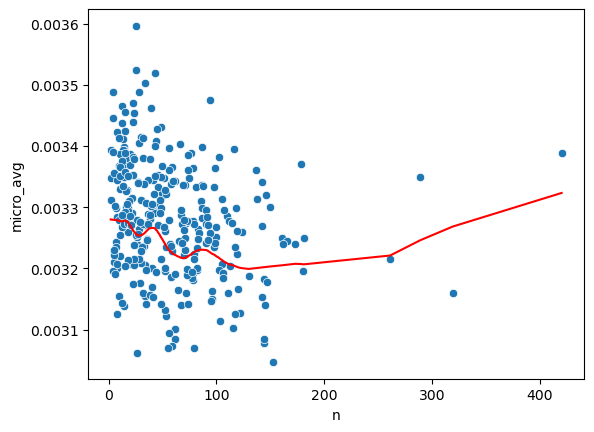

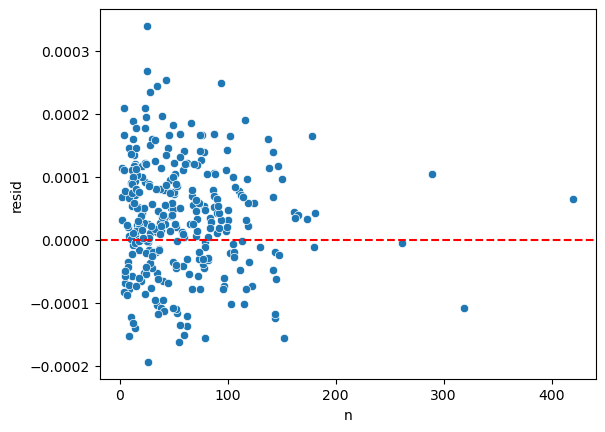

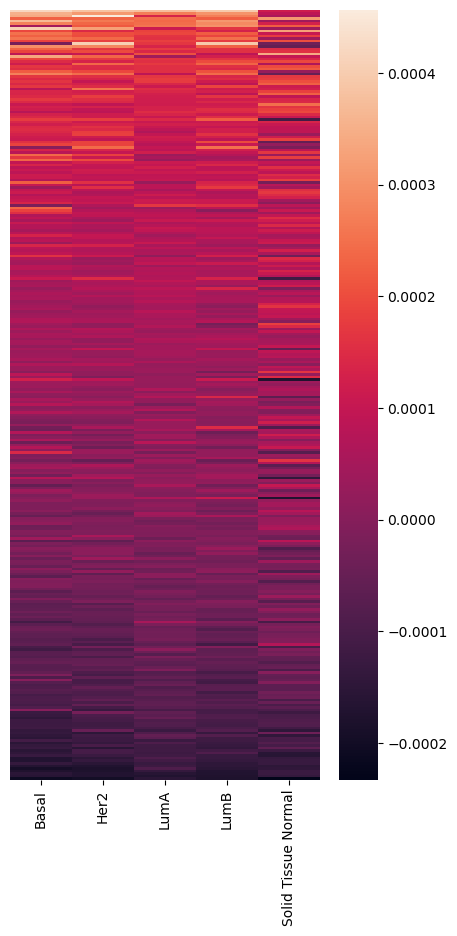

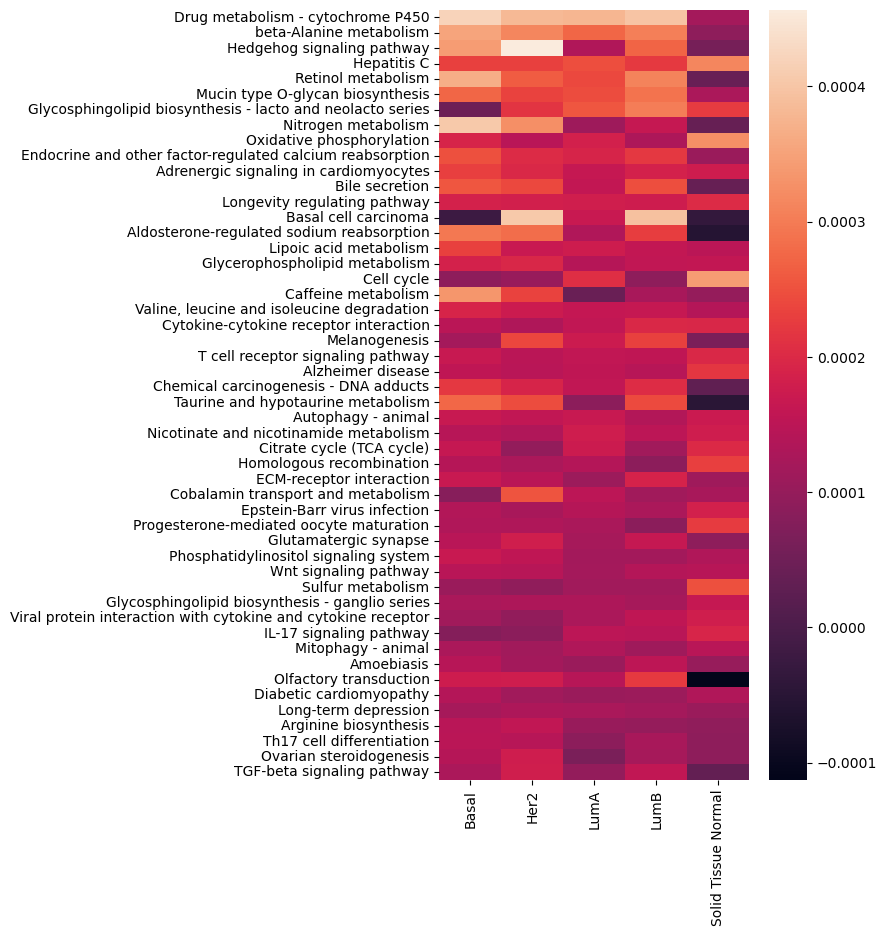

In [34]:
viz = ae
head = 50

display(viz.pathway_stats.sort_values('resid', ascending=False).head(head))
print(viz.pathway_stats.sort_values('resid', ascending=False).head(head).index.tolist())

sns.scatterplot(viz.pathway_stats, x='n', y='micro_avg')
sns.lineplot(viz.pathway_stats, x='n', y='lowess', color='red')
plt.show()

sns.scatterplot(viz.pathway_stats, x='n', y='resid')
plt.axhline(0, color='red', linestyle='--')
plt.show()

plt.figure(figsize=(5,10))
sns.heatmap(viz.pathway_adj.loc[viz.pathway_stats.sort_values('resid', ascending=False).index], yticklabels=False)
plt.show()

plt.figure(figsize=(5,10))
sns.heatmap(viz.pathway_adj.loc[viz.pathway_stats.sort_values('resid', ascending=False).head(50).index])
plt.show()

# plt.figure(figsize=(5,10))
# # sns.clustermap(viz.pathway_adj[(viz.pathway_adj > 0.005).any(axis=1)], yticklabels=False)
# sns.clustermap(viz.pathway_adj, yticklabels=False)

---
# gene

,n,micro_avg,lowess,resid,z
CD40,15.0,0.004257,0.000595,0.003662,16.145812
CD40LG,13.0,0.004038,0.000507,0.003532,15.516807
ADCY9,48.0,0.005189,0.002198,0.002991,11.239333
CD80,10.0,0.003152,0.000380,0.002772,12.167324
CD28,12.0,0.003010,0.000463,0.002547,11.146771
GLS,5.0,0.002730,0.000187,0.002543,11.148670
CD86,10.0,0.002721,0.000380,0.002341,10.233511
GLUD1,5.0,0.002083,0.000187,0.001897,8.148843
FAS,31.0,0.003237,0.001374,0.001863,8.135452
BTD,1.0,0.001786,0.000047,0.001739,7.516736


['CD40', 'CD40LG', 'ADCY9', 'CD80', 'CD28', 'GLS', 'CD86', 'GLUD1', 'FAS', 'BTD', 'DGLUCY', 'HLCS', 'GLUD2', 'FASLG', 'GLUL', 'GOT2', 'IL4I1', 'GOT1', 'PHOSPHO2', 'TAT', 'NAT1', 'CPS1', 'MDM2', 'GNAS', 'TP53', 'ADCY3', 'ADCY5', 'AOX1', 'ADCY4', 'CYP2A6', 'UGT2B15', 'PNPO', 'PAH', 'XDH', 'ENPP3', 'ENPP1', 'PCK1', 'SLC2A5', 'CYP2A7', 'ALDH1B1', 'ALDH3A2', 'PCK2', 'ADH5', 'ADCY6', 'ATP2A2', 'DLD', 'ALDH3A1', 'ALDH7A1', 'ALDH2', 'ICAM1']


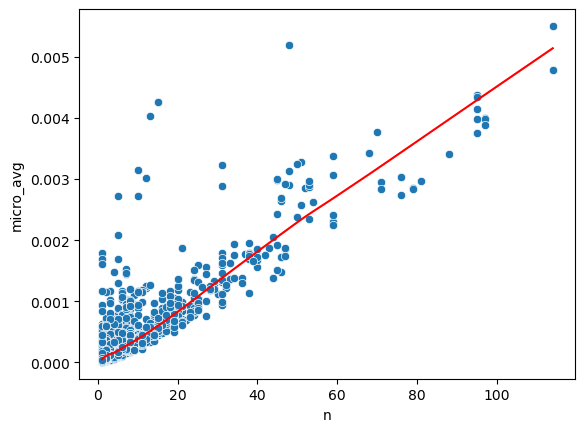

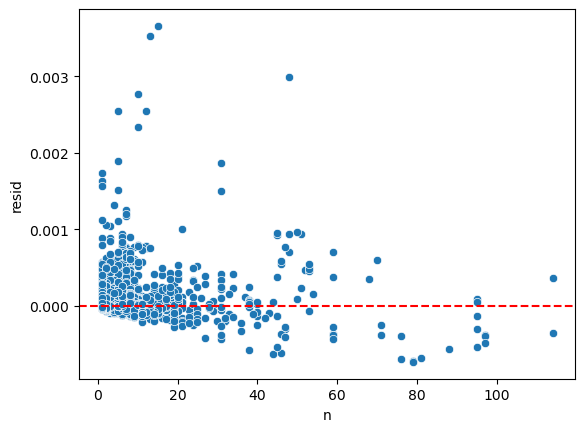

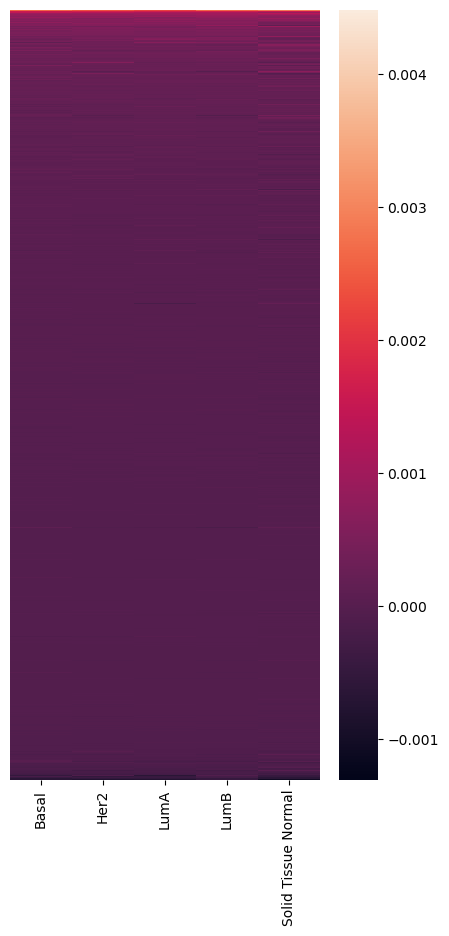

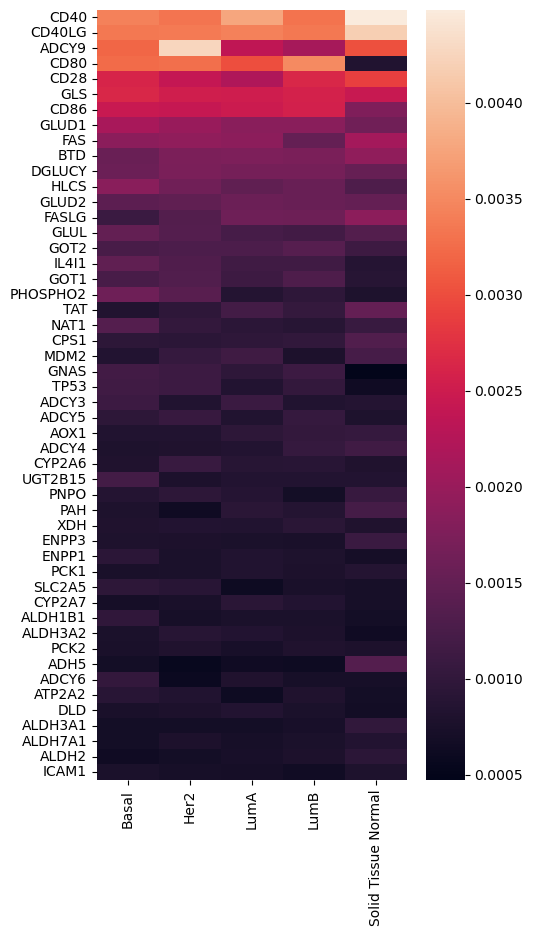

In [24]:
viz = ae
head = 50
stat = 'resid'

display(viz.gene_stats.sort_values(stat, ascending=False).head(head))
print(viz.gene_stats.sort_values(stat, ascending=False).head(head).index.tolist())

sns.scatterplot(viz.gene_stats, x='n', y='micro_avg')
sns.lineplot(viz.gene_stats, x='n', y='lowess', color='red')
plt.show()

sns.scatterplot(viz.gene_stats, x='n', y=stat)
plt.axhline(0, color='red', linestyle='--')
plt.show()

plt.figure(figsize=(5,10))
sns.heatmap(viz.gene_adj.loc[viz.gene_stats.sort_values(stat, ascending=False).index], yticklabels=False)
plt.show()

plt.figure(figsize=(5,10))
sns.heatmap(viz.gene_adj.loc[viz.gene_stats.sort_values(stat, ascending=False).head(50).index])
plt.show()

# plt.figure(figsize=(5,10))
# # sns.clustermap(viz.gene_adj[(viz.gene_adj > 0.005).any(axis=1)], yticklabels=False)
# sns.clustermap(viz.gene_adj, yticklabels=False)

---
# rank (variance stabilization)

In [25]:
# def get_rank(stats_list:list[pd.DataFrame], col:str='z'):
#     mat = pd.concat([df[col].rename(f"trial_{i}") for i,df in enumerate(stats_list)], axis=1)
#     col_std = mat.std(axis=1) + 1e-8
#     rank = mat.mean(axis=1)/col_std
#     return rank, col_std


In [26]:
# pathway_stats['z_std'] = get_rank(pathway_stats_list, 'z')[1]
# pathway_stats['rank'] = get_rank(pathway_stats_list, 'z')[0]

In [27]:
ae.gene_stats.sort_values('resid', ascending=False).head(50)

,n,micro_avg,lowess,resid,z
CD40,15.0,0.004257,0.000595,0.003662,16.145812
CD40LG,13.0,0.004038,0.000507,0.003532,15.516807
ADCY9,48.0,0.005189,0.002198,0.002991,11.239333
CD80,10.0,0.003152,0.000380,0.002772,12.167324
CD28,12.0,0.003010,0.000463,0.002547,11.146771
GLS,5.0,0.002730,0.000187,0.002543,11.148670
CD86,10.0,0.002721,0.000380,0.002341,10.233511
GLUD1,5.0,0.002083,0.000187,0.001897,8.148843
FAS,31.0,0.003237,0.001374,0.001863,8.135452
BTD,1.0,0.001786,0.000047,0.001739,7.516736


<Axes: xlabel='n', ylabel='micro_avg'>

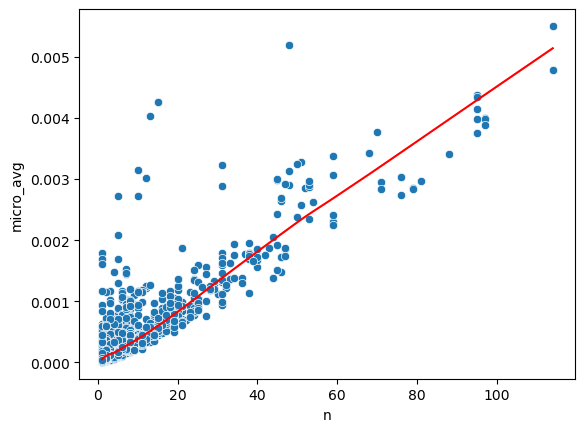

In [28]:
sns.scatterplot(ae.gene_stats, x='n', y='micro_avg')
sns.lineplot(ae.gene_stats, x='n', y='lowess', color='red')

<Axes: >

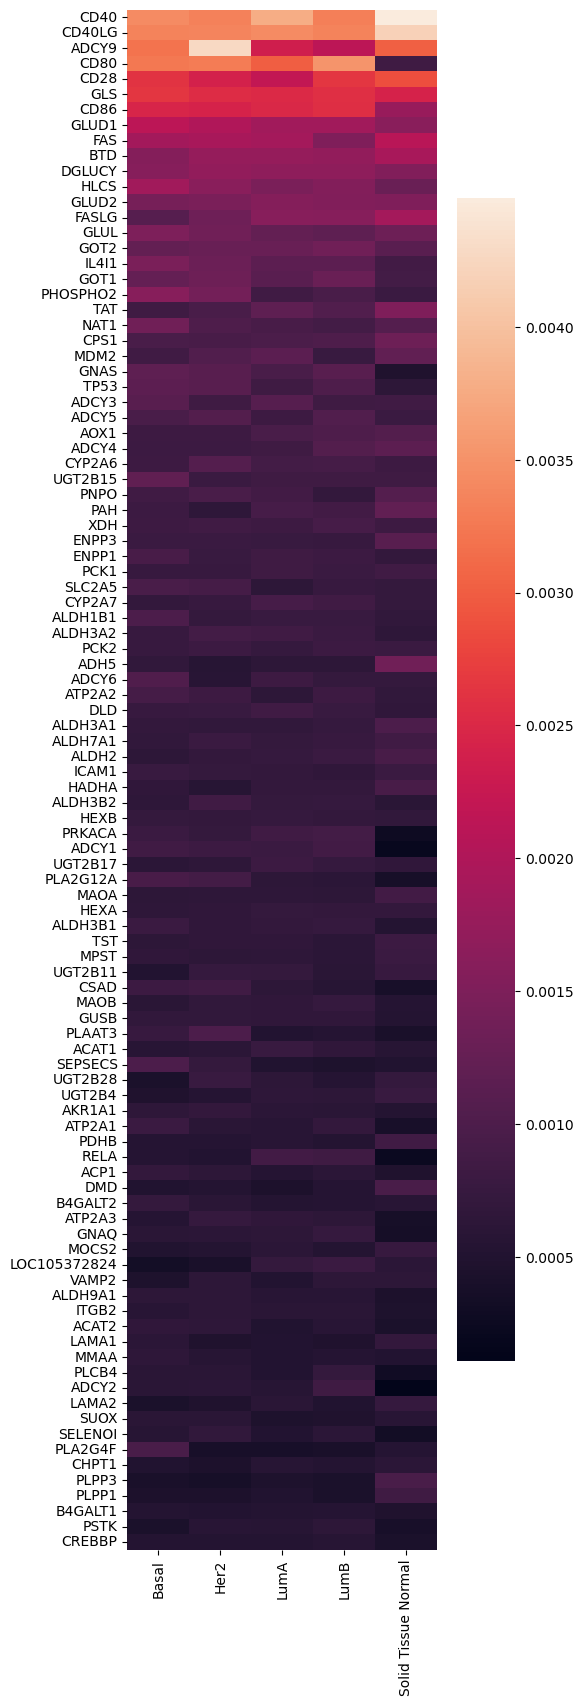

In [29]:
plt.figure(figsize=(5,20))
sns.heatmap(ae.gene_adj.loc[ae.gene_stats.sort_values('resid', ascending=False).index[:100]])

In [30]:
ae.pathway_stats.sort_values('resid', ascending=False).head(50)

,n,micro_avg,lowess,resid,z
Drug metabolism - cytochrome P450,25.0,0.003596,0.003257,0.000339,-0.007339
beta-Alanine metabolism,25.0,0.003524,0.003257,0.000267,0.215948
Hedgehog signaling pathway,43.0,0.003519,0.003266,0.000253,0.117826
Hepatitis C,94.0,0.003476,0.003226,0.000249,0.390544
Retinol metabolism,34.0,0.003503,0.003259,0.000244,0.203512
Mucin type O-glycan biosynthesis,28.0,0.003488,0.003254,0.000234,0.487083
Glycosphingolipid biosynthesis - lacto and neolacto series,23.0,0.003470,0.003261,0.000209,0.108910
Nitrogen metabolism,4.0,0.003488,0.003280,0.000208,0.268084
Oxidative phosphorylation,39.0,0.003461,0.003266,0.000196,0.212870
Endocrine and other factor-regulated calcium reabsorption,24.0,0.003453,0.003260,0.000194,0.089028


<Axes: >

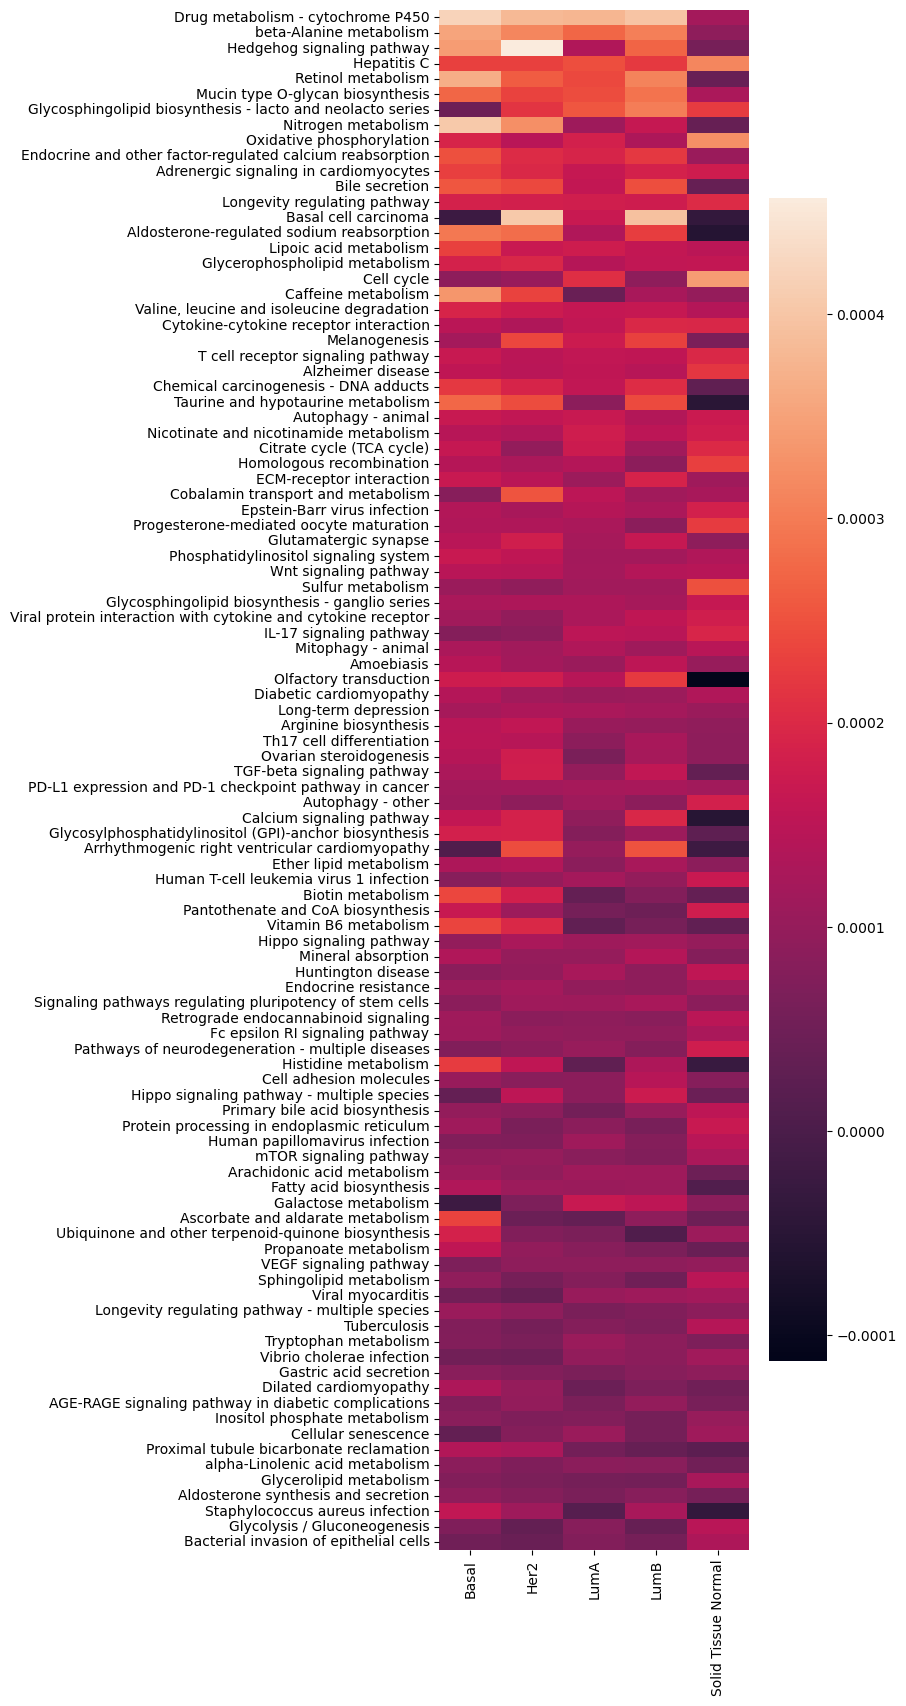

In [31]:
plt.figure(figsize=(5,20))
sns.heatmap(ae.pathway_adj.loc[ae.pathway_stats.sort_values('resid', ascending=False).index[:100]])

ValueError: The number of observations cannot be determined on an empty distance matrix.

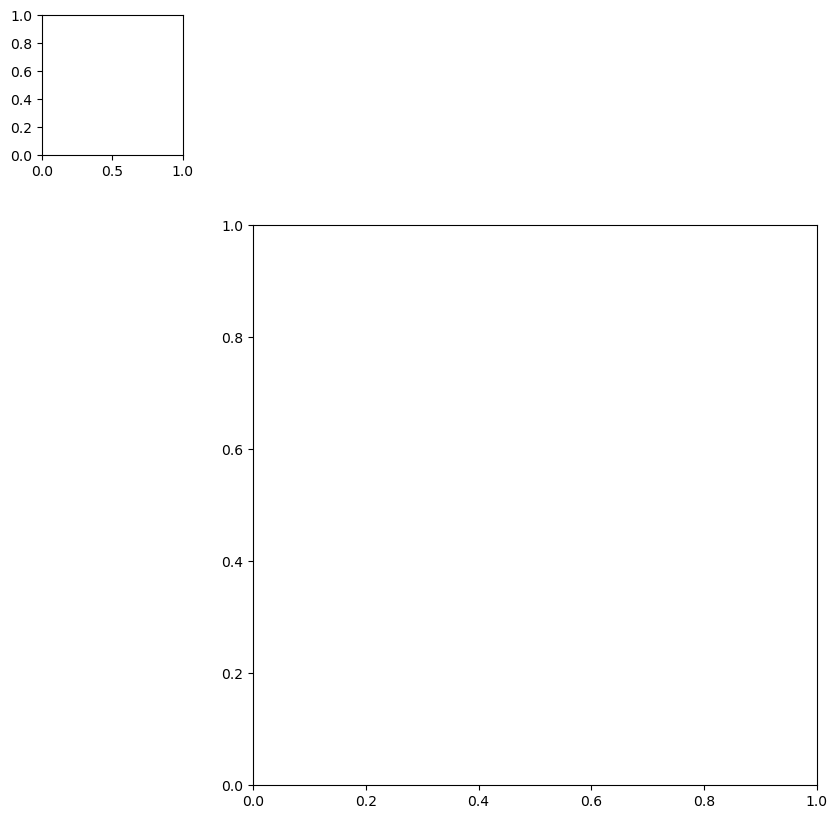

In [32]:
sns.clustermap(ae.pathway_adj[(ae.pathway_adj > (1/305)).any(axis=1)])